# Load libraries and import data

In [ ]:
#####
# Load libraries
#####

suppressPackageStartupMessages(library("tidyverse"))
suppressPackageStartupMessages(library("data.table"))
suppressPackageStartupMessages(library("patchwork"))


#####
# Define variables
#####
input_dir=c('XXXXX') ### Directory containing main tables from the Zenodo repository
output_tables=c('XXXXX') ### Directory to store tables produced by this script
output_figures=c('XXXXX') ### Directory to store figures produced by this script

dir.create(output_tables, recursive = TRUE, showWarnings = FALSE)
dir.create(output_figures, recursive = TRUE, showWarnings = FALSE)


Warning message in dir.create(output_tables):
“'/nfs/nas22/fs2202/biol_micro_sunagawa/Projects/EAN/OMDV2_POPGEN_EAN/scratch/processed/final/output_tables/across_species' already exists”


Warning message in dir.create(output_figures):
“'/nfs/nas22/fs2202/biol_micro_sunagawa/Projects/EAN/OMDV2_POPGEN_EAN/scratch/processed/final/output_figures/across_species' already exists”


In [21]:
#####
# Import gene catalog and gene annotations
#####
sp_all_gene_catalog = fread(file = paste0(input_dir,"species_selected.gene_catalog.tsv"), sep = "\t", header=T) 
sp_all_gene_comp = fread(file = paste0(input_dir,"species_selected.gene_composition_w_annotations.tsv"), sep = "\t", header=T)


# Functions for assessing prevalence, breakpoints and visualising breakpoints

In [22]:
### FUNCTION: calculate prevalence
calculate_prevalence = function(df, group_col, feature_col, exclude_missing = TRUE) {
 
    if (exclude_missing) {
        df = df %>% filter(.data[[feature_col]] != "-", !is.na(.data[[feature_col]]))
    }
 
    total_samples = df %>%
        distinct(across(all_of(group_col)), Sample) %>%
        count(across(all_of(group_col)), name = "total_samples")
 
    feature_prevalence = df %>%
        distinct(across(all_of(c(group_col, feature_col))), Sample) %>%
        count(across(all_of(c(group_col, feature_col))), name = "feature_sample_count") %>%
        left_join(total_samples, by = group_col) %>%
        mutate(prevalence = feature_sample_count / total_samples)
 
    feature_prevalence
}

### FUNCTION: calculate breakpoints
detect_breakpoints = function(prevalence_df, group_col,
                               min_prevalence_for_search = 0.5,
                               top_n = 2) {
 
    all_bins = tibble(prevalence_bin = seq(0, 1, by = 0.01))
 
    groups = prevalence_df %>% distinct(across(all_of(group_col)))
    group_bins = tidyr::crossing(groups, prevalence_bin = all_bins$prevalence_bin)
 
    binned = prevalence_df %>%
        mutate(prevalence_bin = floor(prevalence * 100) / 100) %>%
        count(across(all_of(group_col)), prevalence_bin, name = "count")
 
    binned_full = group_bins %>%
        left_join(binned, by = c(group_col, "prevalence_bin")) %>%
        mutate(count = replace_na(count, 0))
 
    thresholds = binned_full %>%
        group_by(across(all_of(group_col))) %>%
        arrange(desc(prevalence_bin), .by_group = TRUE) %>%
        mutate(bin_index = row_number(), delta = count - lead(count), delta_abs = abs(delta)) %>%
        ungroup()
 
    breakpoints = thresholds %>%
        filter(!is.na(delta_abs), prevalence_bin >= min_prevalence_for_search) %>%
        group_by(across(all_of(group_col))) %>%
        arrange(desc(delta_abs), .by_group = TRUE) %>%
        filter(!duplicated(prevalence_bin)) %>%
        mutate(rank = row_number()) %>%
        filter(rank <= top_n) %>%
        mutate(threshold_type = if_else(rank == 1, "First breakpoint", "Second breakpoint")) %>%
        ungroup() %>%
        rename(prevalence = prevalence_bin)
 
    list(binned_full = binned_full, breakpoints = breakpoints)
}

### FUNCTION: visualise breakpoints
plot_prevalence_breakpoints = function(prevalence_df, breakpoints_df, group_label,
                                        adjust = 1/5) {
 
    density_data = density(prevalence_df$prevalence, adjust = adjust)
    density_df = data.frame(
        prevalence = density_data$x,
        log_density = log10(density_data$y)
    )
 
    breakpoint_bin_counts = breakpoints_df %>%
        mutate(bin = cut(prevalence, breaks = seq(0, 1, by = 0.01), include.lowest = TRUE)) %>%
        group_by(bin, threshold_type) %>%
        summarise(n_groups = n(), .groups = "drop") %>%
        mutate(prevalence = as.numeric(str_extract(as.character(bin), "(?<=\\().+?(?=,)")))
 
    max_log_density = max(density_df$log_density, na.rm = TRUE)
    max_bar_height  = max(breakpoint_bin_counts$n_groups)
    scaling_factor  = max_log_density / max_bar_height
 
    breakpoint_bin_counts = breakpoint_bin_counts %>%
        mutate(scaled_height = n_groups * scaling_factor)
 
    ggplot() +
        geom_line(data = density_df, aes(x = prevalence, y = log_density), color = "black") +
        geom_col(
            data = breakpoint_bin_counts,
            aes(x = prevalence, y = scaled_height, fill = threshold_type),
            width = 0.01, alpha = 0.75, position = "identity"
        ) +
        scale_y_continuous(
            name = "log10(Density of prevalence)",
            sec.axis = sec_axis(~ . / scaling_factor, name = paste0("Number of ", group_label, "s in breakpoint bins"))
        ) +
        scale_fill_manual(values = c("First breakpoint" = "#1f77b4", "Second breakpoint" = "#ff7f0e")) +
        labs(x = "Prevalence") +
        theme_bw() +
        theme(
            legend.position = "bottom",
            legend.title = element_blank(),
            axis.text = element_text(size = 10),
            axis.title = element_text(size = 12)
        )
}

### FUNCTION: extract sample size distributions
report_sample_size_distribution = function(prevalence_df, group_col) {
    prevalence_df %>%
        distinct(across(all_of(group_col)), total_samples) %>%
        summarise(
            n_groups = n(),
            min_samples = min(total_samples),
            median_samples = median(total_samples),
            max_samples = max(total_samples),
            pct_groups_lt_10_samples = mean(total_samples < 10),
            pct_groups_lt_20_samples = mean(total_samples < 20)
        )
}

# Determine species-level core gene cluster content

In [23]:
### Calculate gene prevalence per species
gene_prevalence_per_species = calculate_prevalence(
    sp_all_gene_catalog, group_col = "Species", feature_col = "Gene_catalog_rep",
    exclude_missing = FALSE
)
 
### Extract sample size distributions
report_sample_size_distribution(gene_prevalence_per_species, "Species")

n_groups,min_samples,median_samples,max_samples,pct_groups_lt_10_samples,pct_groups_lt_20_samples
<int>,<int>,<dbl>,<int>,<dbl>,<dbl>
270,20,45,285,0,0


In [24]:
### Calculate and inspect breakpoints
gene_breakpoints_species = detect_breakpoints(gene_prevalence_per_species, "Species")
 
gene_breakpoints_species$breakpoints %>%
    filter(threshold_type == "First breakpoint") %>%
    summarise(median_prevalence = median(prevalence), n = n())


median_prevalence,n
<dbl>,<int>
1,270


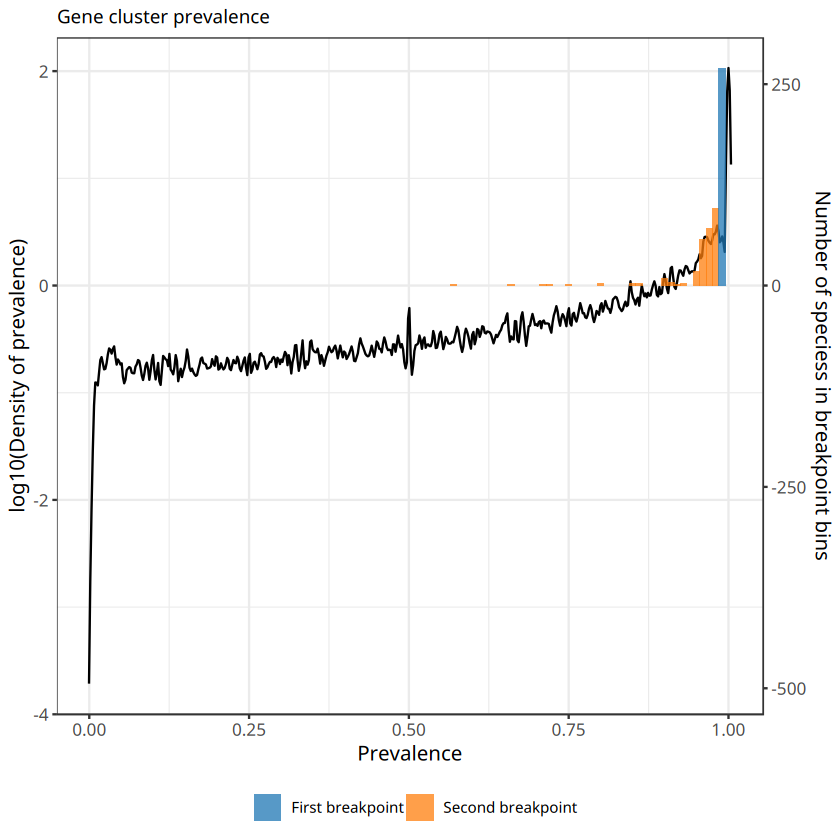

In [26]:
gene_sp_plot = plot_prevalence_breakpoints(
    gene_prevalence_per_species, gene_breakpoints_species$breakpoints, "species"
) + labs(subtitle = "Gene cluster prevalence")

gene_sp_plot

In [27]:
### Species core genome defined as gene clusters with prevalence >=0.99 prevalence
species_core_gene_list = gene_prevalence_per_species %>%
    filter(., prevalence >= 0.99) %>%
    select(Species,Gene_catalog_rep)

fwrite(species_core_gene_list, file=paste0(output_tables,"species_selected.species_core_gene_list.tsv"), sep="\t", quote=F)

# Determine population-level core gene cluster, PFAM and KEGG content

In [29]:
### Combine PFAM and KEGG annotations with gene catalog
subspec_all_gene_catalog_pfam = sp_all_gene_catalog %>%
    left_join(
        sp_all_gene_comp %>% distinct(Gene_catalog_rep, PFAM_accession),
        by = c("Gene_catalog_rep")
    )

subspec_all_gene_catalog_kegg = sp_all_gene_catalog %>%
    left_join(
        sp_all_gene_comp %>% distinct(Gene_catalog_rep, KEGG_ko),
        by = c("Gene_catalog_rep")
    )


In [ ]:
### Calculate prevalences - grouped directly on Species + Subspecies
gene_prevalence_per_subspecies = calculate_prevalence(
    sp_all_gene_catalog, group_col = c("Species", "Subspecies"), feature_col = "Gene_catalog_rep",
    exclude_missing = FALSE
)

pfam_prevalence_per_subspecies = calculate_prevalence(
    subspec_all_gene_catalog_pfam, group_col = c("Species", "Subspecies"), feature_col = "PFAM_accession",
    exclude_missing = TRUE
)
 
kegg_prevalence_per_subspecies = calculate_prevalence(
    subspec_all_gene_catalog_kegg, group_col = c("Species", "Subspecies"), feature_col = "KEGG_ko",
    exclude_missing = TRUE
)

In [ ]:
### Assess where the breakpoints lie across subspecies
gene_breakpoints_subspecies = detect_breakpoints(gene_prevalence_per_subspecies, c("Species", "Subspecies"))
pfam_breakpoints_subspecies  = detect_breakpoints(pfam_prevalence_per_subspecies, c("Species", "Subspecies"))
kegg_breakpoints_subspecies  = detect_breakpoints(kegg_prevalence_per_subspecies, c("Species", "Subspecies"))

gene_breakpoints_subspecies$breakpoints %>%
    filter(threshold_type == "First breakpoint") %>%
    summarise(median_prevalence = median(prevalence), n = n())
 
pfam_breakpoints_subspecies$breakpoints %>%
    filter(threshold_type == "First breakpoint") %>%
    summarise(median_prevalence = median(prevalence), n = n())
 
kegg_breakpoints_subspecies$breakpoints %>%
    filter(threshold_type == "First breakpoint") %>%
    summarise(median_prevalence = median(prevalence), n = n())


median_prevalence,n
<dbl>,<int>
1,690


median_prevalence,n
<dbl>,<int>
1,690


median_prevalence,n
<dbl>,<int>
1,690


Saving 6.67 x 6.67 in image
Saving 6.67 x 6.67 in image


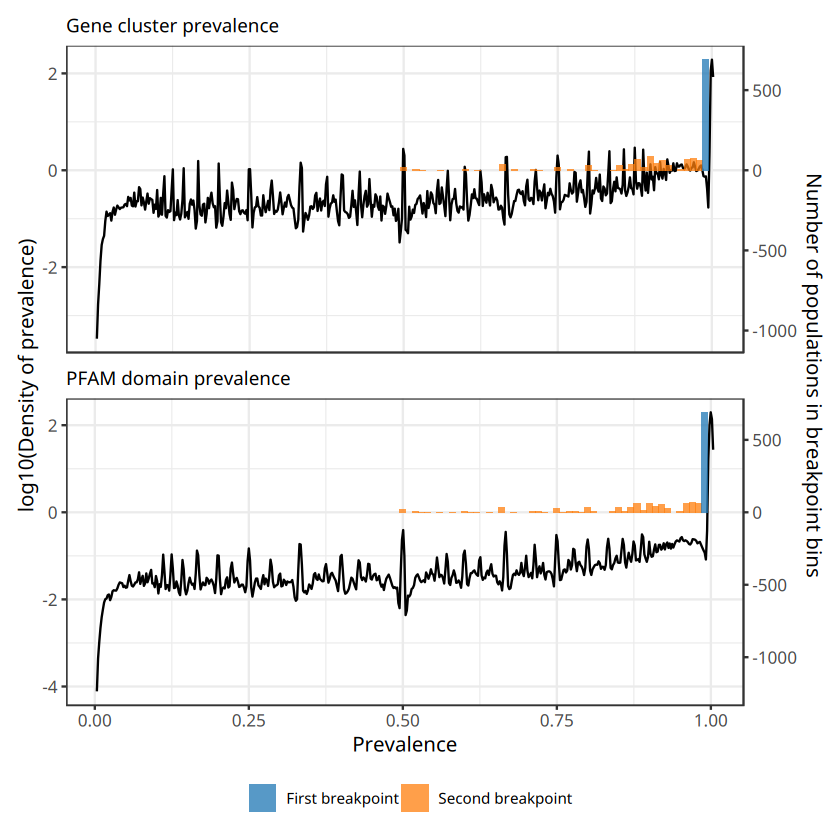

In [34]:
## Visualise gene cluster and Pfam breakpoints
gene_pop_plot = plot_prevalence_breakpoints(
    gene_prevalence_per_subspecies, gene_breakpoints_subspecies$breakpoints, "population"
) + labs(subtitle = "Gene cluster prevalence")
 
pfam_pop_plot = plot_prevalence_breakpoints(
    pfam_prevalence_per_subspecies, pfam_breakpoints_subspecies$breakpoints, "population"
) + labs(subtitle = "PFAM domain prevalence")
 
gene_vs_pfam_subspecies_prevalence = gene_pop_plot / pfam_pop_plot + plot_layout(axes = "collect", guides = "collect") & theme(legend.position = "bottom")
gene_vs_pfam_subspecies_prevalence

ggsave(paste0(output_figures,"species_selected.subspecies.gene_and_pfam_prevalence_breakpoints.pdf"), plot = gene_vs_pfam_subspecies_prevalence, device = "pdf", dpi = 300, units = "in")
ggsave(paste0(output_figures,"species_selected.subspecies.gene_and_pfam_prevalence_breakpoints.png"), plot = gene_vs_pfam_subspecies_prevalence, device = "png", dpi = 300, units = "in")


In [35]:
### Extract subspecies core genome in terms of gene clusters, PFAM and KEGG
pop_core_gene_list = gene_prevalence_per_subspecies %>%
    filter(., prevalence >= 0.99) %>%
    select(Species,Subspecies,Gene_catalog_rep)

pop_core_pfam_list = pfam_prevalence_per_subspecies %>%
    filter(., prevalence >= 0.99) %>%
    select(Species,Subspecies,PFAM_accession)

pop_core_ko_list = kegg_prevalence_per_subspecies %>%
    filter(., prevalence >= 0.99) %>%
    select(Species,Subspecies,KEGG_ko)

fwrite(pop_core_gene_list, file=paste0(output_tables,"species_selected.subspecies.core_gene_list.tsv"), sep="\t", quote=F)
fwrite(pop_core_pfam_list, file=paste0(output_tables,"species_selected.subspecies.core_pfam_list.tsv"), sep="\t", quote=F)
fwrite(pop_core_ko_list, file=paste0(output_tables,"species_selected.subspecies.core_kegg_list.tsv"), sep="\t", quote=F)
